In [2]:
# intern

import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist 

from matplotlib import pyplot as plt

# --- Zufällige Datenmatrix ---
np.random.seed(420)
X, y = make_blobs(n_samples=150, centers=5, cluster_std=1, random_state=40)

# --- Visualisierung ---
# plt.scatter(*X.T, c=y)
# plt.show()

del y

# --- Aufteiling in train und test Daten ---
X_train, X_valid = train_test_split(X, train_size=0.8, test_size=0.2, random_state=40)

# --- Clusterung -> y ---
K = 8
centroids = KMeans(n_clusters=K, n_init="auto", random_state=42).fit(X_train).cluster_centers_
y = KMeans(n_clusters=K, n_init="auto", random_state=42).fit_predict(X_valid)

# --- Prediction Strength ---
rck = np.argmin(cdist(X_valid, centroids), axis=1)
comembership_matrix = np.array([[c == c_ for c_ in rck] for c in rck], dtype=int)

prediction_strength = min([
    1/((y == j).sum() * ((y == j).sum() - 1)) * np.sum([[
        comembership_matrix[*i,*i_] if i != i_ else 0
        for i_ in np.argwhere(y == j)]
    for i in np.argwhere(y == j)]) if (y == j).sum() > 1 else np.inf
for j in range(K)
])

In [3]:
def get_comembership_matrix(X_valid, train_centroids):
    rck = np.argmin(cdist(X_valid, train_centroids), axis=1)
    return np.array([[c == c_ for c_ in rck] for c in rck], dtype=int)

def get_prediction_strength(M, valid_labels, K):
    return min([1/((valid_labels == j).sum() * ((valid_labels == j).sum() - 1)) * np.sum([[M[*i,*i_] if i != i_ else 0 for i_ in np.argwhere(valid_labels == j)] for i in np.argwhere(valid_labels == j)]) if (valid_labels == j).sum() > 1 else np.inf for j in range(K)])

In [4]:
# Prediction Stregth nach Clusteranzahl ---
prediction_strengths = []
Ks = range(1, 9)
for K in Ks:
    centroids = KMeans(n_clusters=K, n_init="auto", random_state=42).fit(X_train).cluster_centers_
    y = KMeans(n_clusters=K, n_init="auto", random_state=42).fit_predict(X_valid)

    M = get_comembership_matrix(X_valid, centroids)
    prediction_strengths.append(get_prediction_strength(M, y, K))

# --- Visualisierung ---
# plt.plot(Ks, prediction_strengths)
# plt.xlabel("Clusteranzahl ($K$)")
# plt.ylabel("Prediction Strength")
# plt.show()

print(f"K={np.argmax(prediction_strengths[1:]) + 2}")

K=3


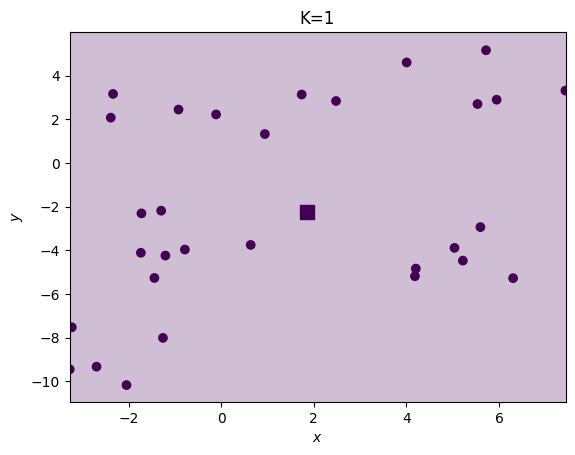

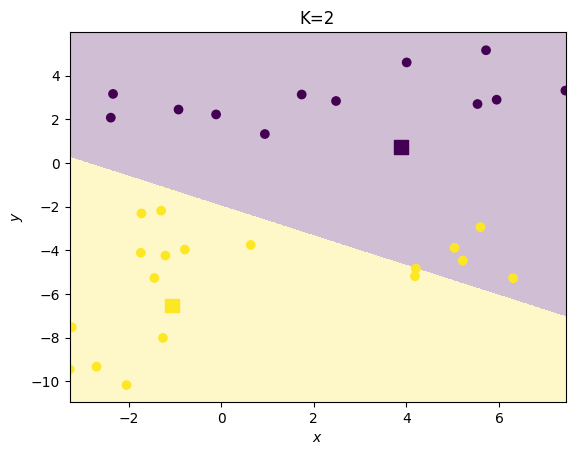

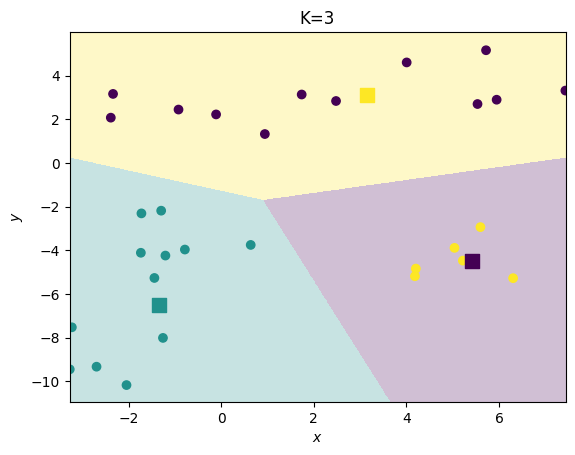

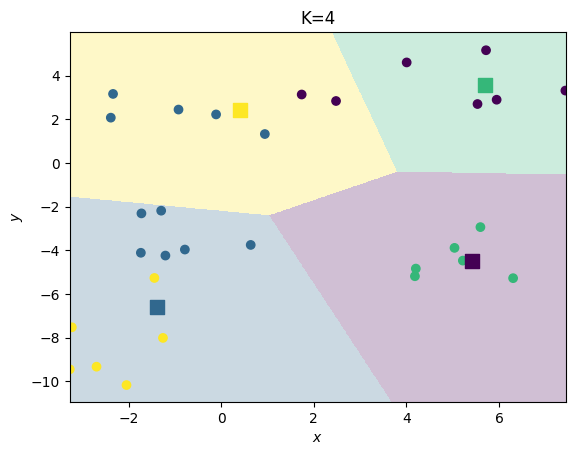

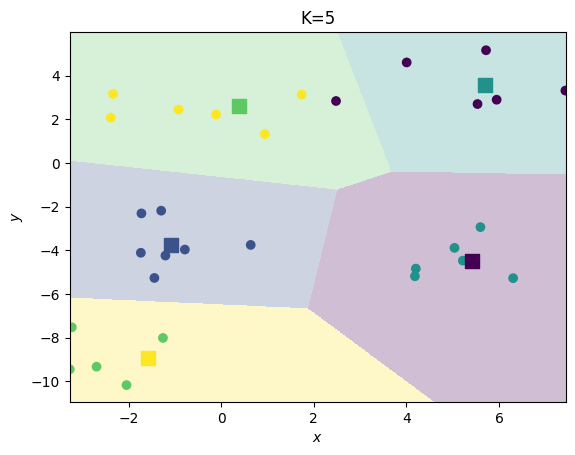

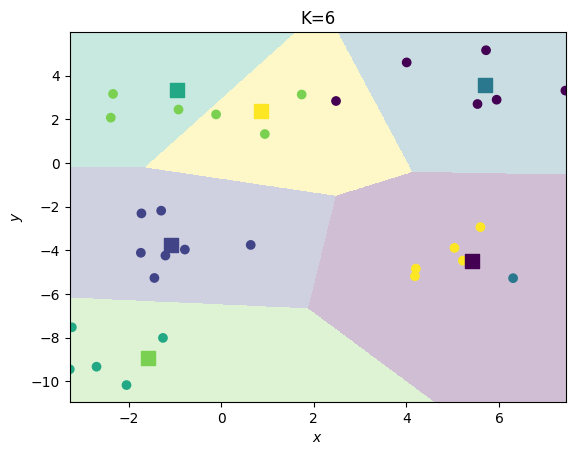

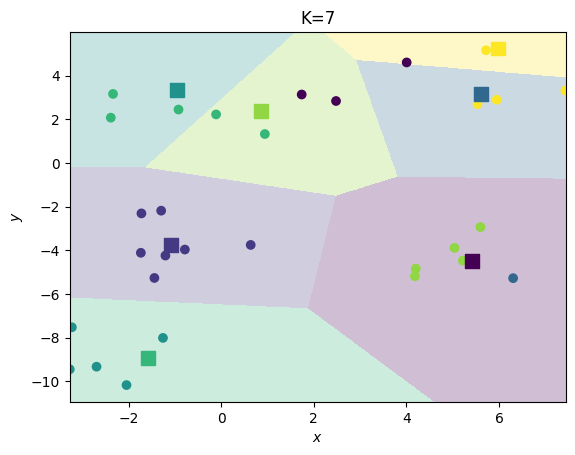

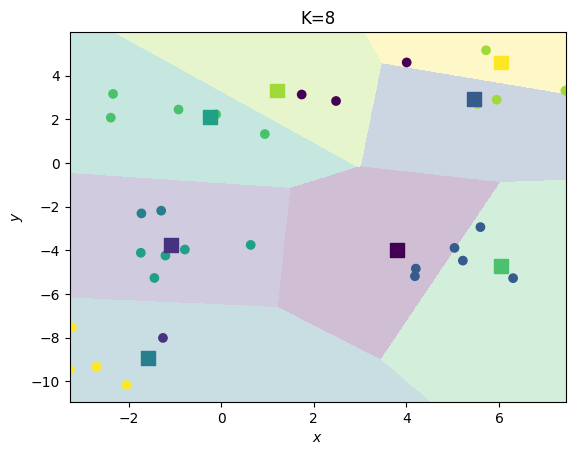

In [5]:
for K in Ks:
    centroids = KMeans(n_clusters=K, n_init="auto", random_state=42).fit(X_train).cluster_centers_
    y = KMeans(n_clusters=K, n_init="auto", random_state=42).fit_predict(X_valid)

    h = 0.01
    lims = np.vstack([X.min(axis=0), X.max(axis=0).T]).T
    xx, yy = np.meshgrid(np.arange(*lims[0], h), np.arange(*lims[1], h))

    colors = np.argmin(cdist(np.vstack([xx.ravel(), yy.ravel()]).T, centroids), axis=1)
    plt.pcolormesh(xx, yy, colors.reshape(xx.shape), alpha=0.25)

    plt.scatter(*X_valid.T, c=y)
    plt.scatter(*centroids.T, c=range(centroids.shape[0]), marker="s", s=100)

    plt.title(f"{K=}")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.show()